In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from pathlib import Path
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                            confusion_matrix, classification_report)
from sklearn.model_selection import KFold, train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.utils import to_categorical

2025-12-03 04:15:06.059429: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# ==================================================
# DISABLE XLA (prevent ptxas errors)
# ==================================================
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ['TF_XLA_FLAGS'] = '--tf_xla_auto_jit="0"'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
tf.config.run_functions_eagerly(True)

In [3]:

# Verify GPU
print("=" * 60)
print("GPU SETUP CHECK")
print("=" * 60)
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU Available: {gpus}")
print(f"GPU Count: {len(gpus)}")
if gpus:
    print(f"Using: {gpus[0].name}")
print(f"Built with CUDA: {tf.test.is_built_with_cuda()}")

# ==================================================
# CONFIGURATION
# ==================================================
tf.random.set_seed(42)
np.random.seed(42)

GPU SETUP CHECK
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU Count: 1
Using: /physical_device:GPU:0
Built with CUDA: True


In [4]:
# Paths
DATASET_PATH = "../ACV_CNN/dataset/mri/Train"
SAVE_PATH = "training/results_mri_multiclass"
MODEL_PATH = "multiclass_classification_model.keras"
HISTORY_PATH = "training_history2.npy"

# Training parameters
IMG_SIZE = (256, 256)
NUM_CHANNELS = 3
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 0.0001

# Data split ratios
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# Classes
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(CLASS_NAMES)

# Cross-validation parameters
USE_CROSS_VALIDATION = False  # Set to True to enable k-fold CV
K_FOLDS = 5

# Evaluation parameters
CONFIDENCE_THRESHOLD = 0.7

os.makedirs(SAVE_PATH, exist_ok=True)


In [5]:
# ==================================================
# DATA LOADING AND SPLITTING
# ==================================================
def load_and_split_data(data_path, class_names, train_ratio=0.70, val_ratio=0.15, test_ratio=0.15):
    """Load all images and split into train/val/test sets."""
    
    print("\n" + "=" * 60)
    print("LOADING AND SPLITTING DATA")
    print("=" * 60)
    
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 0.01, "Ratios must sum to 1.0"
    
    all_images = []
    all_labels = []
    
    class_map = {name: idx for idx, name in enumerate(sorted(class_names))}
    print(f"\nClass mapping: {class_map}")
    
    for class_name in sorted(class_names):
        class_path = os.path.join(data_path, class_name)
        if not os.path.isdir(class_path):
            print(f"⚠️  Warning: Directory not found - {class_path}")
            continue
        
        label = class_map[class_name]
        class_images = []
        
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                img = load_img(img_path, target_size=IMG_SIZE, color_mode='rgb')
                img_array = img_to_array(img) / 255.0
                class_images.append(img_array)
                all_labels.append(label)
            except Exception as e:
                print(f"Error loading {img_path}: {e}")
        
        all_images.extend(class_images)
        print(f"  {class_name}: {len(class_images)} images")
    
    X = np.array(all_images)
    y = np.array(all_labels)
    
    print(f"\nTotal samples loaded: {len(X)}")
    
    # First split: separate test set
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=test_ratio, random_state=42, stratify=y
    )
    
    # Second split: separate train and val from remaining data
    val_size_adjusted = val_ratio / (train_ratio + val_ratio)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_size_adjusted, random_state=42, stratify=y_temp
    )
    
    print(f"\nData split:")
    print(f"  Training:   {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
    print(f"  Validation: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
    print(f"  Test:       {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
    
    # Print class distribution
    print(f"\nClass distribution:")
    for split_name, split_labels in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
        print(f"  {split_name}:")
        for class_name, class_idx in sorted(class_map.items(), key=lambda x: x[1]):
            count = np.sum(split_labels == class_idx)
            print(f"    {class_name}: {count}")
    
    return X_train, X_val, X_test, y_train, y_val, y_test, class_map


In [6]:
# ==================================================
# BUILD CNN ARCHITECTURE
# ==================================================
def build_cnn_model_deep(img_size=(256, 256), channels=3, num_classes=4):
    """DEEP CNN (10 conv layers) for multi-class classification."""
    
    model = models.Sequential([
        layers.Input(shape=(img_size[0], img_size[1], channels)),
        
        # First block
        layers.Conv2D(16, kernel_size=5, strides=1, padding='same', activation='relu'),
        layers.Conv2D(16, kernel_size=5, strides=1, padding='same', activation='relu'),
        layers.Dropout(0.25),
        layers.AveragePooling2D(pool_size=2, strides=2),
        
        # Second block
        layers.Conv2D(32, kernel_size=3, strides=1, padding='same', activation='relu'),
        layers.Conv2D(32, kernel_size=3, strides=1, padding='same', activation='relu'),
        layers.Dropout(0.25),
        layers.AveragePooling2D(pool_size=2, strides=2),
        
        # Third block
        layers.Conv2D(64, kernel_size=7, strides=1, padding='same', activation='relu'),
        layers.Conv2D(64, kernel_size=7, strides=1, padding='same', activation='relu'),
        layers.Conv2D(64, kernel_size=7, strides=1, padding='same', activation='relu'),
        layers.Dropout(0.25),
        layers.MaxPooling2D(pool_size=2, strides=2),
        
        # Fourth block
        layers.Conv2D(128, kernel_size=3, strides=1, padding='same', activation='relu'),
        layers.Conv2D(128, kernel_size=3, strides=1, padding='same', activation='relu'),
        layers.Conv2D(128, kernel_size=3, strides=1, padding='same', activation='relu'),
        layers.Dropout(0.25),
        layers.MaxPooling2D(pool_size=2, strides=2),
        
        # Flatten
        layers.Flatten(),
        
        # Dense layers
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        
        # Output layer with softmax for multi-class
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model


In [7]:
# ==================================================
# OVERFITTING/UNDERFITTING DETECTION
# ==================================================
def detect_model_fit_status(history, train_acc=None, val_acc=None):
    """Comprehensive detection of overfitting, underfitting, or good fit."""
    if history is None:
        return "UNKNOWN", {}
    
    train_losses = history.get('loss', [])
    val_losses = history.get('val_loss', [])
    train_accs = history.get('accuracy', [])
    val_accs = history.get('val_accuracy', [])
    
    if not train_losses or not val_losses:
        return "INSUFFICIENT_DATA", {}
    
    final_train_loss = train_losses[-1]
    final_val_loss = val_losses[-1]
    final_train_acc = train_accs[-1] if train_accs else train_acc
    final_val_acc = val_accs[-1] if val_accs else val_acc
    
    loss_gap = final_val_loss - final_train_loss
    acc_gap = final_train_acc - final_val_acc if final_train_acc and final_val_acc else 0
    val_loss_variance = np.var(val_losses[-10:]) if len(val_losses) >= 10 else 0
    train_loss_improvement = train_losses[0] - final_train_loss if len(train_losses) > 1 else 0
    
    details = {
        'final_train_loss': final_train_loss,
        'final_val_loss': final_val_loss,
        'final_train_acc': final_train_acc,
        'final_val_acc': final_val_acc,
        'loss_gap': loss_gap,
        'acc_gap': acc_gap,
        'val_loss_variance': val_loss_variance,
        'train_loss_improvement': train_loss_improvement
    }
    
    if loss_gap > 0.3 or acc_gap > 0.15:
        if final_train_acc and final_train_acc > 0.9:
            return "SEVERE_OVERFITTING", details
        return "OVERFITTING", details
    
    if final_train_acc and final_train_acc < 0.7:
        if train_loss_improvement < 0.1:
            return "SEVERE_UNDERFITTING", details
        return "UNDERFITTING", details
    
    if val_loss_variance > 0.05:
        return "HIGH_VARIANCE", details
    
    if acc_gap < 0.08 and final_train_acc and final_train_acc >= 0.75:
        return "GOOD_FIT", details
    
    if acc_gap < 0.12:
        return "ACCEPTABLE_FIT", details
    
    return "UNKNOWN", details


In [8]:


def format_fit_status_report(status, details):
    """Format a detailed report of model fit status."""
    
    status_colors = {
        'GOOD_FIT': '\033[92m', 'ACCEPTABLE_FIT': '\033[94m',
        'OVERFITTING': '\033[93m', 'SEVERE_OVERFITTING': '\033[91m',
        'UNDERFITTING': '\033[93m', 'SEVERE_UNDERFITTING': '\033[91m',
        'HIGH_VARIANCE': '\033[93m', 'UNKNOWN': '\033[90m'
    }
    
    status_icons = {
        'GOOD_FIT': '✅', 'ACCEPTABLE_FIT': '✓',
        'OVERFITTING': '⚠️', 'SEVERE_OVERFITTING': '❌',
        'UNDERFITTING': '⚠️', 'SEVERE_UNDERFITTING': '❌',
        'HIGH_VARIANCE': '⚠️', 'UNKNOWN': '❓'
    }
    
    recommendations = {
        'GOOD_FIT': ["Model is performing well!", "Consider deploying this model"],
        'ACCEPTABLE_FIT': ["Model shows reasonable performance", "Could benefit from minor tuning"],
        'OVERFITTING': ["Increase dropout rates", "Add more data augmentation", "Use early stopping"],
        'SEVERE_OVERFITTING': ["CRITICAL: Model memorizing data", "Significantly increase dropout", "Collect more training data"],
        'UNDERFITTING': ["Increase model capacity", "Train for more epochs", "Reduce dropout rates"],
        'SEVERE_UNDERFITTING': ["CRITICAL: Model cannot learn", "Increase model complexity", "Check data quality"],
        'HIGH_VARIANCE': ["Validation loss is unstable", "Increase batch size", "Reduce learning rate"]
    }
    
    color = status_colors.get(status, '\033[0m')
    icon = status_icons.get(status, '•')
    reset = '\033[0m'
    
    report = f"\n{'='*60}\n"
    report += f"{color}MODEL FIT STATUS: {icon} {status}{reset}\n"
    report += f"{'='*60}\n\n"
    report += "METRICS:\n"
    report += f"  Training Accuracy:    {details.get('final_train_acc', 0):.4f}\n"
    report += f"  Validation Accuracy:  {details.get('final_val_acc', 0):.4f}\n"
    report += f"  Accuracy Gap:         {details.get('acc_gap', 0):.4f}\n"
    report += f"  Training Loss:        {details.get('final_train_loss', 0):.4f}\n"
    report += f"  Validation Loss:      {details.get('final_val_loss', 0):.4f}\n"
    report += f"  Loss Gap:             {details.get('loss_gap', 0):.4f}\n\n"
    
    if status in recommendations:
        report += "RECOMMENDATIONS:\n"
        for i, rec in enumerate(recommendations[status], 1):
            report += f"  {i}. {rec}\n"
    
    return report


In [9]:

# ==================================================
# TRAINING
# ==================================================
def train_model(X_train, X_val, X_test, y_train, y_val, y_test):
    """Train the CNN model from scratch."""
    
    print("\n" + "=" * 60)
    print("TRAINING PHASE")
    print("=" * 60)
    
    # Convert labels to categorical
    y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
    y_val_cat = to_categorical(y_val, num_classes=NUM_CLASSES)
    y_test_cat = to_categorical(y_test, num_classes=NUM_CLASSES)
    
    print(f"\nTraining samples: {len(X_train)}")
    print(f"Validation samples: {len(X_val)}")
    print(f"Test samples: {len(X_test)}")
    
    # Build model
    model = build_cnn_model_deep(IMG_SIZE, channels=NUM_CHANNELS, num_classes=NUM_CLASSES)
    print("\nModel Architecture:")
    model.summary()
    
    # Compile model
    model.compile(
        optimizer=AdamW(learning_rate=LEARNING_RATE, weight_decay=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    print(f"\nOptimizer: AdamW (lr={LEARNING_RATE})")
    print(f"Loss Function: Categorical Crossentropy")
    
    # Callbacks
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1)
    
    # Data augmentation
    datagen = ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        horizontal_flip=True,
        zoom_range=0.2,
        shear_range=0.2,
        fill_mode='nearest'
    )
    
    print("\n" + "=" * 60)
    print("STARTING TRAINING")
    print("=" * 60)
    
    try:
        history = model.fit(
            datagen.flow(X_train, y_train_cat, batch_size=BATCH_SIZE),
            steps_per_epoch=len(X_train) // BATCH_SIZE,
            epochs=EPOCHS,
            validation_data=(X_val, y_val_cat),
            callbacks=[early_stop, reduce_lr],
            verbose=1
        )
        print(f"\n✅ Training completed!")
        
    except Exception as e:
        print(f"\n❌ Training failed with error: {e}")
        raise
    
    # Detect fit status
    status, details = detect_model_fit_status(history.history)
    print(format_fit_status_report(status, details))
    
    # Save model and history
    print("\n" + "=" * 60)
    print("SAVING MODEL")
    print("=" * 60)
    
    model.save(MODEL_PATH)
    save_data = {
        'history': history.history,
        'fit_status': status,
        'fit_details': details
    }
    np.save(HISTORY_PATH, save_data)
    print(f"✅ Model saved as '{MODEL_PATH}'")
    print(f"✅ History saved as '{HISTORY_PATH}'")
    
    return model, history


In [10]:
# ==================================================
# EVALUATION
# ==================================================
def analyze_dataset_split(model, X, y, split_name):
    """Analyze a specific dataset split."""
    print(f"\nAnalyzing {split_name} set...")
    
    all_preds = []
    all_truths = []
    all_probs = []
    all_confidence = []
    
    # Batch prediction for efficiency
    batch_size = 32
    for i in range(0, len(X), batch_size):
        batch_X = X[i:i+batch_size]
        batch_y = y[i:i+batch_size]
        
        pred_probs = model.predict(batch_X, verbose=0)
        pred_classes = np.argmax(pred_probs, axis=1)
        confidences = np.max(pred_probs, axis=1)
        
        all_preds.extend(pred_classes)
        all_truths.extend(batch_y)
        all_probs.extend(pred_probs)
        all_confidence.extend(confidences)
    
    needs_verification = np.array(all_confidence) < CONFIDENCE_THRESHOLD
    
    return {
        'preds': np.array(all_preds),
        'truths': np.array(all_truths),
        'probs': np.array(all_probs),
        'confidence': np.array(all_confidence),
        'needs_verification': needs_verification
    }


In [11]:

def create_visualizations(model, train_results, val_results, test_results, hist_data, save_dir, class_names):
    """Create comprehensive analysis visualizations."""
    
    fig = plt.figure(figsize=(20, 16))
    gs = fig.add_gridspec(5, 3, hspace=0.4, wspace=0.35)
    
    # Extract history
    if isinstance(hist_data, dict) and 'history' in hist_data:
        history = hist_data['history']
        status = hist_data.get('fit_status', 'UNKNOWN')
        details = hist_data.get('fit_details', {})
    else:
        history = hist_data
        status, details = detect_model_fit_status(history)
    
    # 1. Training Loss
    ax1 = fig.add_subplot(gs[0, 0])
    if history:
        epochs = range(1, len(history['loss']) + 1)
        ax1.plot(epochs, history['loss'], 'b-', label='Training Loss', linewidth=2)
        if 'val_loss' in history:
            ax1.plot(epochs, history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.set_title('Training & Validation Loss', fontweight='bold')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
    
    # 2. Training Accuracy
    ax2 = fig.add_subplot(gs[0, 1])
    if history:
        ax2.plot(epochs, history['accuracy'], 'b-', label='Training Accuracy', linewidth=2)
        if 'val_accuracy' in history:
            ax2.plot(epochs, history['val_accuracy'], 'r-', label='Validation Accuracy', linewidth=2)
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy')
        ax2.set_title('Training & Validation Accuracy', fontweight='bold')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    
    # 3. Fit Status
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.axis('off')
    status_text = f"""
FIT STATUS: {status}

Train Acc: {details.get('final_train_acc', 0):.4f}
Val Acc: {details.get('final_val_acc', 0):.4f}
Acc Gap: {details.get('acc_gap', 0):.4f}

Train Loss: {details.get('final_train_loss', 0):.4f}
Val Loss: {details.get('final_val_loss', 0):.4f}
Loss Gap: {details.get('loss_gap', 0):.4f}
    """
    ax3.text(0.1, 0.5, status_text, fontsize=10, family='monospace',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3),
            verticalalignment='center')
    
    # 4-6. Confusion Matrices
    datasets = [
        (train_results, 'Training', gs[1, 0]),
        (val_results, 'Validation', gs[1, 1]),
        (test_results, 'Test', gs[1, 2])
    ]
    
    for data, name, pos in datasets:
        ax = fig.add_subplot(pos)
        if data:
            cm = confusion_matrix(data['truths'], data['preds'])
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                       xticklabels=class_names, yticklabels=class_names,
                       cbar=False)
            acc = accuracy_score(data['truths'], data['preds'])
            ax.set_title(f'{name}\nAcc: {acc:.2%}', fontweight='bold')
            ax.set_xlabel('Predicted')
            ax.set_ylabel('True')
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
            plt.setp(ax.yaxis.get_majorticklabels(), rotation=0)
    
    # 7. Per-class accuracy
    ax7 = fig.add_subplot(gs[2, 0])
    if test_results:
        class_accuracies = []
        for class_idx in range(len(class_names)):
            mask = test_results['truths'] == class_idx
            if np.sum(mask) > 0:
                class_acc = accuracy_score(test_results['truths'][mask], 
                                          test_results['preds'][mask])
                class_accuracies.append(class_acc)
            else:
                class_accuracies.append(0)
        
        bars = ax7.bar(class_names, class_accuracies, color='steelblue', alpha=0.7)
        ax7.set_ylabel('Accuracy')
        ax7.set_title('Per-Class Accuracy (Test)', fontweight='bold')
        ax7.set_ylim([0, 1.1])
        plt.setp(ax7.xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        for bar, acc in zip(bars, class_accuracies):
            height = bar.get_height()
            ax7.text(bar.get_x() + bar.get_width()/2., height,
                    f'{acc:.1%}', ha='center', va='bottom', fontsize=9)
        ax7.grid(True, alpha=0.3, axis='y')
    
    # 8. Confidence distribution
    ax8 = fig.add_subplot(gs[2, 1])
    if test_results:
        ax8.hist(test_results['confidence'], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
        ax8.axvline(CONFIDENCE_THRESHOLD, color='red', linestyle='--', 
                   linewidth=2, label=f'Threshold ({CONFIDENCE_THRESHOLD})')
        ax8.set_xlabel('Confidence')
        ax8.set_ylabel('Count')
        ax8.set_title('Confidence Distribution (Test)', fontweight='bold')
        ax8.legend()
        ax8.grid(True, alpha=0.3, axis='y')
    
    # 9. Metrics comparison
    ax9 = fig.add_subplot(gs[2, 2])
    metric_names = ['Accuracy', 'Precision', 'Recall', 'F1']
    x = np.arange(len(metric_names))
    width = 0.25
    
    for i, (data, name, color) in enumerate([
        (train_results, 'Train', '#3498db'),
        (val_results, 'Val', '#f39c12'),
        (test_results, 'Test', '#2ecc71')
    ]):
        if data:
            metrics = [
                accuracy_score(data['truths'], data['preds']),
                precision_score(data['truths'], data['preds'], average='weighted', zero_division=0),
                recall_score(data['truths'], data['preds'], average='weighted', zero_division=0),
                f1_score(data['truths'], data['preds'], average='weighted', zero_division=0)
            ]
            ax9.bar(x + i*width, metrics, width, label=name, color=color, alpha=0.8)
    
    ax9.set_ylabel('Score')
    ax9.set_title('Metrics Comparison', fontweight='bold')
    ax9.set_xticks(x + width)
    ax9.set_xticklabels(metric_names)
    ax9.legend()
    ax9.set_ylim([0, 1.1])
    ax9.grid(True, alpha=0.3, axis='y')
    
    # 10. Learning curve
    if history and 'val_loss' in history:
        ax10 = fig.add_subplot(gs[3, :2])
        epochs = range(1, len(history['loss']) + 1)
        
        window = min(5, len(history['loss']))
        if len(history['loss']) >= window:
            train_loss_ma = np.convolve(history['loss'], np.ones(window)/window, mode='valid')
            val_loss_ma = np.convolve(history['val_loss'], np.ones(window)/window, mode='valid')
            ma_epochs = range(window, len(history['loss']) + 1)
            
            ax10.plot(epochs, history['loss'], 'b-', alpha=0.3, linewidth=1)
            ax10.plot(epochs, history['val_loss'], 'r-', alpha=0.3, linewidth=1)
            ax10.plot(ma_epochs, train_loss_ma, 'b-', linewidth=2, label='Train Loss (MA)')
            ax10.plot(ma_epochs, val_loss_ma, 'r-', linewidth=2, label='Val Loss (MA)')
        
        ax10.set_xlabel('Epoch')
        ax10.set_ylabel('Loss')
        ax10.set_title('Learning Curve', fontweight='bold')
        ax10.legend()
        ax10.grid(True, alpha=0.3)
        
        # 11. Loss gap
        ax11 = fig.add_subplot(gs[3, 2])
        loss_gaps = np.array(history['val_loss']) - np.array(history['loss'])
        ax11.plot(epochs, loss_gaps, 'purple', linewidth=2)
        ax11.axhline(y=0, color='black', linestyle='--', linewidth=1)
        ax11.fill_between(epochs, 0, loss_gaps, where=(loss_gaps > 0), 
                        color='red', alpha=0.3, label='Overfitting')
        ax11.fill_between(epochs, loss_gaps, 0, where=(loss_gaps < 0), 
                        color='blue', alpha=0.3, label='Underfitting')
        ax11.set_xlabel('Epoch')
        ax11.set_ylabel('Loss Gap')
        ax11.set_title('Overfitting/Underfitting Trend', fontweight='bold')
        ax11.legend()
        ax11.grid(True, alpha=0.3)
    
    # 12. Summary
    ax12 = fig.add_subplot(gs[4, :])
    ax12.axis('off')
    
    if test_results:
        total = len(test_results['truths'])
        accuracy = accuracy_score(test_results['truths'], test_results['preds'])
        needs_review = np.sum(test_results['needs_verification'])
        f1 = f1_score(test_results['truths'], test_results['preds'], average='weighted')
        
        class_summary = ""
        for class_idx, class_name in enumerate(class_names):
            mask = test_results['truths'] == class_idx
            if np.sum(mask) > 0:
                class_acc = accuracy_score(test_results['truths'][mask], test_results['preds'][mask])
                class_summary += f"  • {class_name}: {class_acc:.2%} (n={np.sum(mask)})\n"
        
        summary_text = f"""
TEST SET SUMMARY

Overall Performance:
  • Total Samples: {total}
  • Accuracy: {accuracy:.2%}
  • Weighted F1 Score: {f1:.4f}
  • Samples Needing Review: {needs_review} ({needs_review/total:.1%})

Per-Class Performance:
{class_summary}
Model Fit Status: {status}
  • Training Accuracy: {details.get('final_train_acc', 0):.4f}
  • Validation Accuracy: {details.get('final_val_acc', 0):.4f}
  • Accuracy Gap: {details.get('acc_gap', 0):.4f}
        """
        
        ax12.text(0.1, 0.5, summary_text, fontsize=10, family='monospace',
                 bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.3),
                 verticalalignment='center')
    
    # Save figure
    output_file = os.path.join(save_dir, "comprehensive_analysis.png")
    plt.savefig(output_file, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    
    print(f"\n✅ Comprehensive analysis saved: {output_file}")
    return test_results


In [12]:
# ==================================================
# MAIN EXECUTION
# ==================================================
def main():
    """Main execution function."""
    
    print("\n" + "=" * 60)
    print("MULTI-CLASS CNN TRAINING & EVALUATION PIPELINE")
    print(f"Classes: {CLASS_NAMES}")
    print("=" * 60)
    
    # Load and split data
    print("\nLoading dataset...")
    X_train, X_val, X_test, y_train, y_val, y_test, class_map = load_and_split_data(
        DATASET_PATH, CLASS_NAMES, TRAIN_RATIO, VAL_RATIO, TEST_RATIO
    )
    
    # Check if model exists
    if os.path.exists(MODEL_PATH):
        print(f"\n⚠️  Model already exists: {MODEL_PATH}")
        response = input("Choose: (T)rain new or (E)valuate existing? [T/E]: ").strip().upper()
        
        if response == 'T':
            model, history = train_model(X_train, X_val, X_test, y_train, y_val, y_test)
            history_dict = history.history
        else:
            print("\nLoading existing model...")
            model = tf.keras.models.load_model(MODEL_PATH)
            print("✅ Model loaded")
            
            if os.path.exists(HISTORY_PATH):
                loaded_data = np.load(HISTORY_PATH, allow_pickle=True).item()
                if isinstance(loaded_data, dict) and 'history' in loaded_data:
                    history_dict = loaded_data
                else:
                    history_dict = loaded_data
                print("✅ History loaded")
            else:
                history_dict = None
                print("⚠️  History not found")
    else:
        model, history = train_model(X_train, X_val, X_test, y_train, y_val, y_test)
        history_dict = history.history
    
    # Evaluation phase
    print("\n" + "=" * 60)
    print("EVALUATION PHASE")
    print("=" * 60)
    
    # Analyze all splits
    train_results = analyze_dataset_split(model, X_train, y_train, "TRAINING")
    val_results = analyze_dataset_split(model, X_val, y_val, "VALIDATION")
    test_results = analyze_dataset_split(model, X_test, y_test, "TEST")
    
    # Create visualizations
    test_results = create_visualizations(
        model, train_results, val_results, test_results, 
        history_dict, SAVE_PATH, CLASS_NAMES
    )
    
    # Print classification report
    print("\n" + "=" * 60)
    print("CLASSIFICATION REPORT (TEST SET)")
    print("=" * 60)
    print(classification_report(test_results['truths'], test_results['preds'], 
                               target_names=CLASS_NAMES, digits=4))
    
    # Final summary
    if test_results and history_dict:
        print("\n" + "=" * 60)
        print("FINAL SUMMARY")
        print("=" * 60)
        
        # Extract fit status
        if isinstance(history_dict, dict):
            if 'fit_status' in history_dict:
                status = history_dict['fit_status']
                details = history_dict.get('fit_details', {})
            else:
                status, details = detect_model_fit_status(history_dict)
        else:
            status, details = 'UNKNOWN', {}
        
        print(format_fit_status_report(status, details))
        
        total = len(test_results['truths'])
        accuracy = accuracy_score(test_results['truths'], test_results['preds'])
        needs_review = np.sum(test_results['needs_verification'])
        
        print(f"\nTest Set Performance:")
        print(f"  Total samples: {total}")
        print(f"  Overall accuracy: {accuracy:.2%}")
        print(f"  Weighted F1 Score: {f1_score(test_results['truths'], test_results['preds'], average='weighted'):.4f}")
        print(f"  Requiring human review: {needs_review} ({needs_review/total:.1%})")
        
        # Per-class summary
        print(f"\nPer-Class Accuracy:")
        for class_idx, class_name in enumerate(CLASS_NAMES):
            mask = test_results['truths'] == class_idx
            if np.sum(mask) > 0:
                class_acc = accuracy_score(test_results['truths'][mask], test_results['preds'][mask])
                print(f"  {class_name:15s}: {class_acc:.2%} (n={np.sum(mask):4d})")
        
        print(f"\n✅ All results saved to: {SAVE_PATH}")
    
    print("\n" + "=" * 60)
    print("PIPELINE COMPLETE!")
    print("=" * 60)


In [13]:
kernel_size=5, 3, 7, 3


MULTI-CLASS CNN TRAINING & EVALUATION PIPELINE
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

Loading dataset...

LOADING AND SPLITTING DATA

Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
  glioma: 1620 images
  meningioma: 1525 images
  notumor: 1334 images
  pituitary: 1738 images

Total samples loaded: 6217

Data split:
  Training:   4351 (70.0%)
  Validation: 933 (15.0%)
  Test:       933 (15.0%)

Class distribution:
  Train:
    glioma: 1134
    meningioma: 1067
    notumor: 934
    pituitary: 1216
  Val:
    glioma: 243
    meningioma: 229
    notumor: 200
    pituitary: 261
  Test:
    glioma: 243
    meningioma: 229
    notumor: 200
    pituitary: 261

TRAINING PHASE

Training samples: 4351
Validation samples: 933
Test samples: 933


2025-12-03 04:15:25.895841: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1764731725.897000  190762 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6153 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9



Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 16)   │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 256, 16)   │         6,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256, 256, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 128, 128, 16)   │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 64, 64, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    16,777,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,02

...

Epoch 1/100


/home/lina/Desktop/Aubery/chatbot/.venv/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(
2025-12-03 04:15:27.370912: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


135/135 ━━━━━━━━━━━━━━━━━━━━ 55s 325ms/step - accuracy: 0.3598 - loss: 1.2819 - val_accuracy: 0.5788 - val_loss: 1.0645 - learning_rate: 1.0000e-04
Epoch 2/100
  1/135 ━━━━━━━━━━━━━━━━━━━━ 20s 154ms/step - accuracy: 0.5938 - loss: 1.0190

/home/lina/Desktop/Aubery/chatbot/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5938 - loss: 1.0190 - val_accuracy: 0.5413 - val_loss: 1.0706 - learning_rate: 1.0000e-04
Epoch 3/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 36s 266ms/step - accuracy: 0.5643 - loss: 1.0054 - val_accuracy: 0.6538 - val_loss: 0.8609 - learning_rate: 1.0000e-04
Epoch 4/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7188 - loss: 0.7245 - val_accuracy: 0.6613 - val_loss: 0.8636 - learning_rate: 1.0000e-04
Epoch 5/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 36s 264ms/step - accuracy: 0.6559 - loss: 0.8575 - val_accuracy: 0.6656 - val_loss: 0.7788 - learning_rate: 1.0000e-04
Epoch 6/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6562 - loss: 0.8253 - val_accuracy: 0.6763 - val_loss: 0.7715 - learning_rate: 1.0000e-04
Epoch 7/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 35s 261ms/step - accuracy: 0.6828 - loss: 0.7835 - val_accuracy: 0.6827 - val_loss: 0.7126 - learning_rate: 1.0000e-04
Epoch 8/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - acc

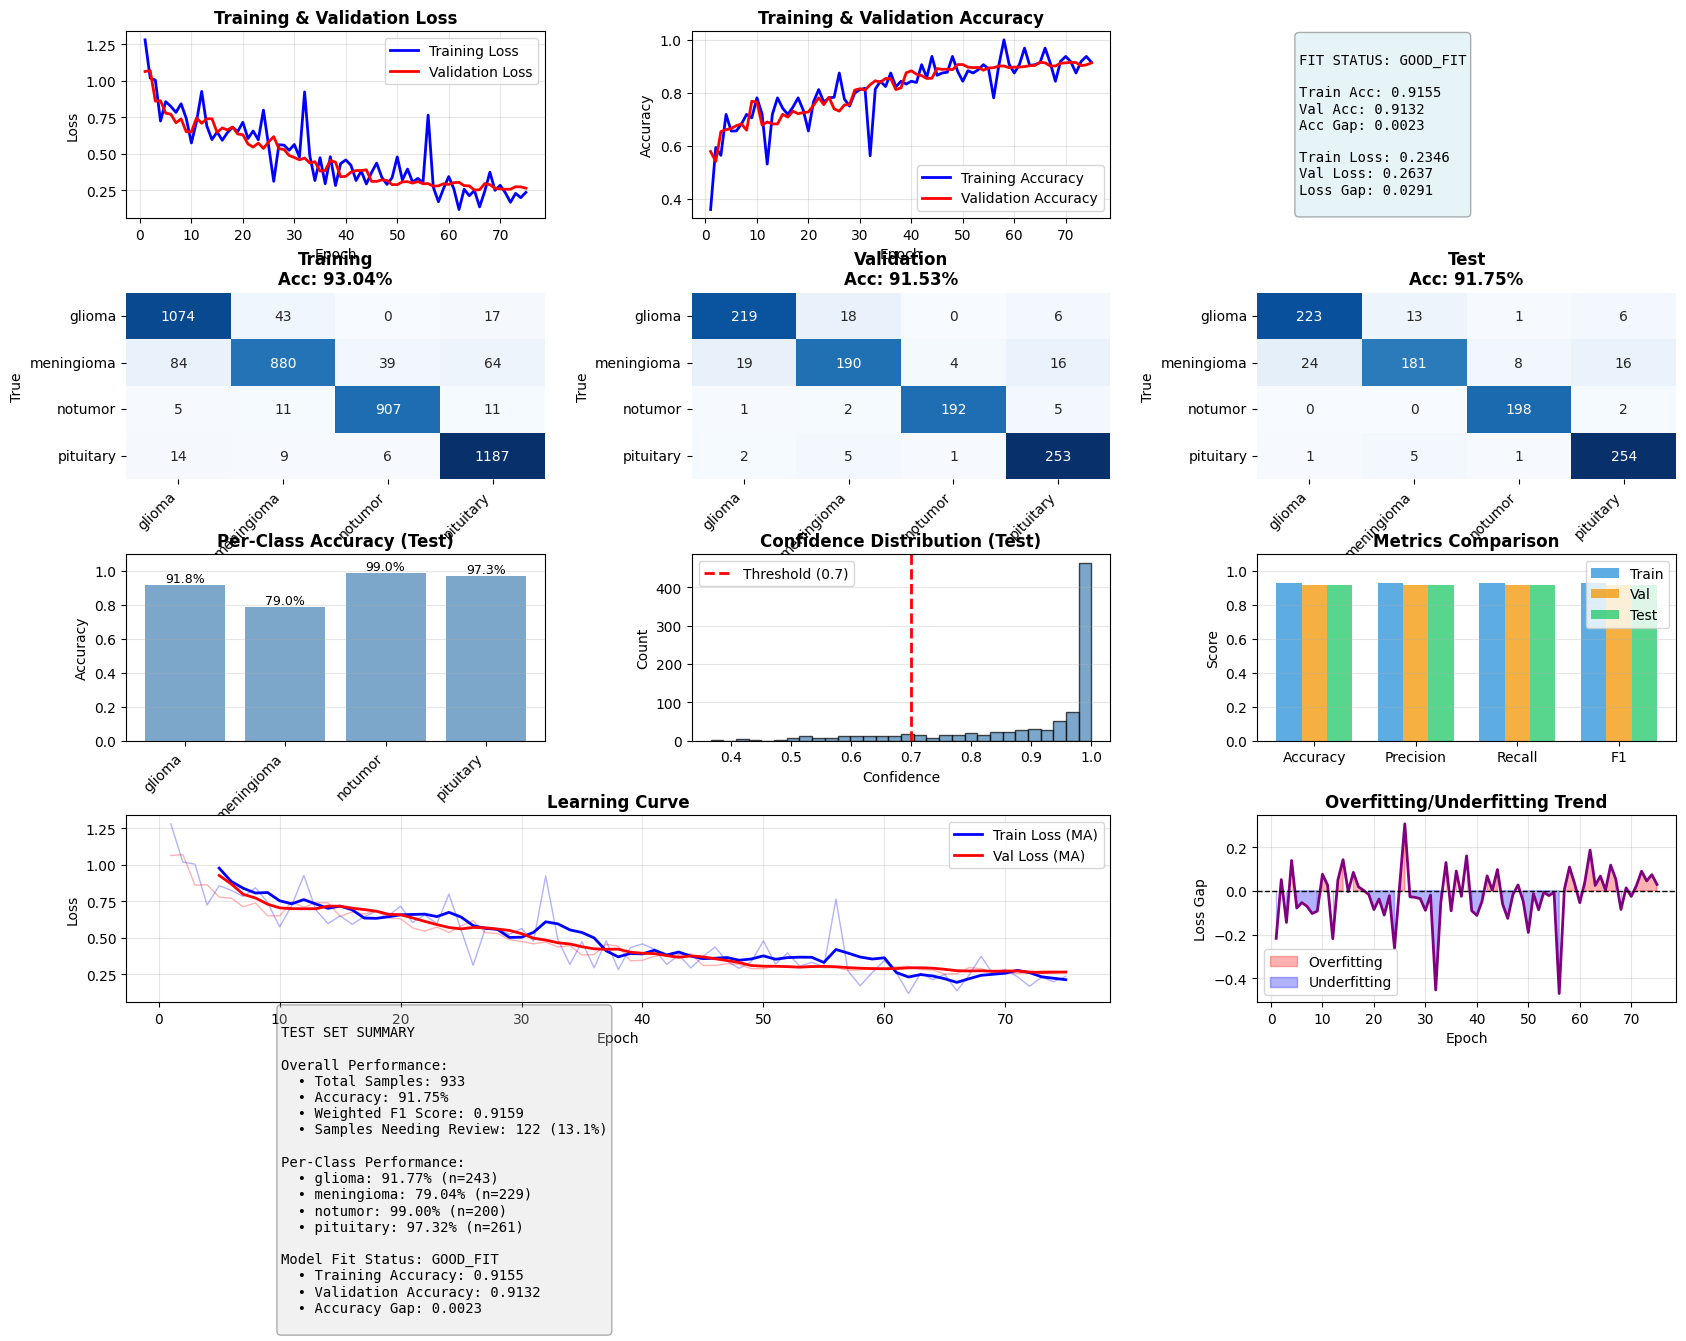


✅ Comprehensive analysis saved: training/results_mri_multiclass/comprehensive_analysis.png

CLASSIFICATION REPORT (TEST SET)
              precision    recall  f1-score   support

      glioma     0.8992    0.9177    0.9084       243
  meningioma     0.9095    0.7904    0.8458       229
     notumor     0.9519    0.9900    0.9706       200
   pituitary     0.9137    0.9732    0.9425       261

    accuracy                         0.9175       933
   macro avg     0.9186    0.9178    0.9168       933
weighted avg     0.9171    0.9175    0.9159       933


FINAL SUMMARY

MODEL FIT STATUS: ✅ GOOD_FIT

METRICS:
  Training Accuracy:    0.9155
  Validation Accuracy:  0.9132
  Accuracy Gap:         0.0023
  Training Loss:        0.2346
  Validation Loss:      0.2637
  Loss Gap:             0.0291

RECOMMENDATIONS:
  1. Model is performing well!
  2. Consider deploying this model


Test Set Performance:
  Total samples: 933
  Overall accuracy: 91.75%
  Weighted F1 Score: 0.9159
  Requiring hu

In [15]:

if __name__ == "__main__":
    main()

kernel_size=3, 3, 3, 3


MULTI-CLASS CNN TRAINING & EVALUATION PIPELINE
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

Loading dataset...

LOADING AND SPLITTING DATA

Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
  glioma: 1620 images
  meningioma: 1525 images
  notumor: 1334 images
  pituitary: 1738 images

Total samples loaded: 6217

Data split:
  Training:   4351 (70.0%)
  Validation: 933 (15.0%)
  Test:       933 (15.0%)

Class distribution:
  Train:
    glioma: 1134
    meningioma: 1067
    notumor: 934
    pituitary: 1216
  Val:
    glioma: 243
    meningioma: 229
    notumor: 200
    pituitary: 261
  Test:
    glioma: 243
    meningioma: 229
    notumor: 200
    pituitary: 261

TRAINING PHASE

Training samples: 4351
Validation samples: 933
Test samples: 933


2025-12-03 03:26:06.995299: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1764728766.996267  165669 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6153 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9



Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 256, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256, 256, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 128, 128, 16)   │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 64, 64, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    16,777,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,02

...

Epoch 1/100


/home/lina/Desktop/Aubery/chatbot/.venv/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(
2025-12-03 03:26:08.249792: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


135/135 ━━━━━━━━━━━━━━━━━━━━ 48s 299ms/step - accuracy: 0.3987 - loss: 1.2329 - val_accuracy: 0.5230 - val_loss: 1.0607 - learning_rate: 1.0000e-04
Epoch 2/100
  1/135 ━━━━━━━━━━━━━━━━━━━━ 18s 137ms/step - accuracy: 0.5000 - loss: 1.0419

/home/lina/Desktop/Aubery/chatbot/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5000 - loss: 1.0419 - val_accuracy: 0.4512 - val_loss: 1.1085 - learning_rate: 1.0000e-04
Epoch 3/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 33s 244ms/step - accuracy: 0.5987 - loss: 0.9686 - val_accuracy: 0.5895 - val_loss: 0.9301 - learning_rate: 1.0000e-04
Epoch 4/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7188 - loss: 0.9239 - val_accuracy: 0.5884 - val_loss: 0.9442 - learning_rate: 1.0000e-04
Epoch 5/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 31s 231ms/step - accuracy: 0.6610 - loss: 0.8613 - val_accuracy: 0.6249 - val_loss: 0.9077 - learning_rate: 1.0000e-04
Epoch 6/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6875 - loss: 0.6853 - val_accuracy: 0.6345 - val_loss: 0.8774 - learning_rate: 1.0000e-04
Epoch 7/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 31s 231ms/step - accuracy: 0.6888 - loss: 0.7907 - val_accuracy: 0.6667 - val_loss: 0.7766 - learning_rate: 1.0000e-04
Epoch 8/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accura

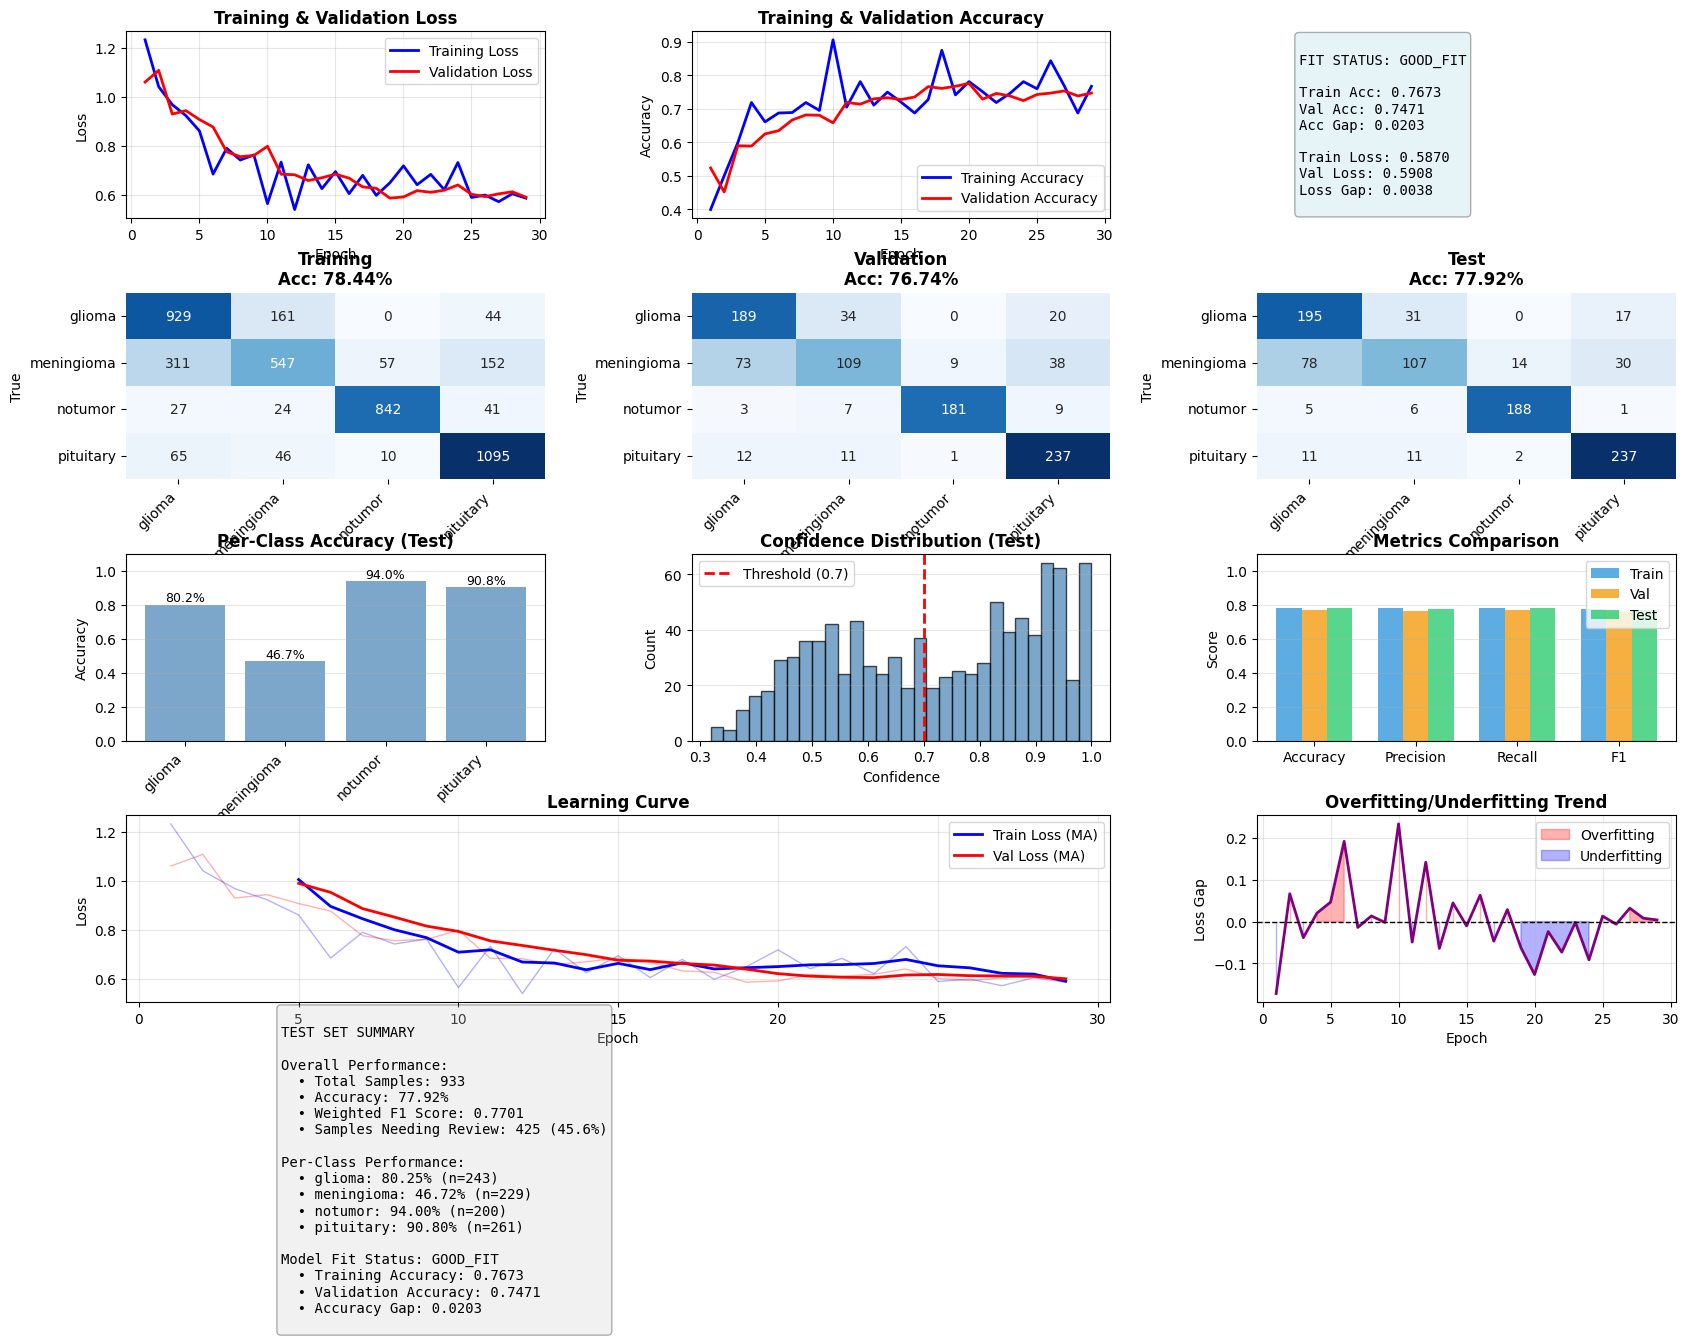


✅ Comprehensive analysis saved: training/results_mri_multiclass/comprehensive_analysis.png

CLASSIFICATION REPORT (TEST SET)
              precision    recall  f1-score   support

      glioma     0.6747    0.8025    0.7331       243
  meningioma     0.6903    0.4672    0.5573       229
     notumor     0.9216    0.9400    0.9307       200
   pituitary     0.8316    0.9080    0.8681       261

    accuracy                         0.7792       933
   macro avg     0.7796    0.7794    0.7723       933
weighted avg     0.7754    0.7792    0.7701       933


FINAL SUMMARY

MODEL FIT STATUS: ✅ GOOD_FIT

METRICS:
  Training Accuracy:    0.7673
  Validation Accuracy:  0.7471
  Accuracy Gap:         0.0203
  Training Loss:        0.5870
  Validation Loss:      0.5908
  Loss Gap:             0.0038

RECOMMENDATIONS:
  1. Model is performing well!
  2. Consider deploying this model


Test Set Performance:
  Total samples: 933
  Overall accuracy: 77.92%
  Weighted F1 Score: 0.7701
  Requiring hu

In [ ]:

if __name__ == "__main__":
    main()

kernel_size=7, 5, 3, 3


MULTI-CLASS CNN TRAINING & EVALUATION PIPELINE
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

Loading dataset...

LOADING AND SPLITTING DATA

Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
  glioma: 1620 images
  meningioma: 1525 images
  notumor: 1334 images
  pituitary: 1738 images

Total samples loaded: 6217

Data split:
  Training:   4351 (70.0%)
  Validation: 933 (15.0%)
  Test:       933 (15.0%)

Class distribution:
  Train:
    glioma: 1134
    meningioma: 1067
    notumor: 934
    pituitary: 1216
  Val:
    glioma: 243
    meningioma: 229
    notumor: 200
    pituitary: 261
  Test:
    glioma: 243
    meningioma: 229
    notumor: 200
    pituitary: 261

TRAINING PHASE

Training samples: 4351
Validation samples: 933
Test samples: 933


2025-12-03 02:40:41.785857: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1764726041.786864  140367 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6153 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9



Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 16)   │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 256, 16)   │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256, 256, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 128, 128, 16)   │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │        12,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 64, 64, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    16,777,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,02

...

Epoch 1/100


/home/lina/Desktop/Aubery/chatbot/.venv/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(
2025-12-03 02:40:43.290441: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


135/135 ━━━━━━━━━━━━━━━━━━━━ 52s 309ms/step - accuracy: 0.3992 - loss: 1.2375 - val_accuracy: 0.6227 - val_loss: 0.9866 - learning_rate: 1.0000e-04
Epoch 2/100
  1/135 ━━━━━━━━━━━━━━━━━━━━ 20s 151ms/step - accuracy: 0.5938 - loss: 1.0149

/home/lina/Desktop/Aubery/chatbot/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5938 - loss: 1.0149 - val_accuracy: 0.6217 - val_loss: 0.9828 - learning_rate: 1.0000e-04
Epoch 3/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 33s 247ms/step - accuracy: 0.5476 - loss: 1.0293 - val_accuracy: 0.6270 - val_loss: 0.9422 - learning_rate: 1.0000e-04
Epoch 4/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4375 - loss: 1.1904 - val_accuracy: 0.6345 - val_loss: 0.9254 - learning_rate: 1.0000e-04
Epoch 5/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 33s 247ms/step - accuracy: 0.6133 - loss: 0.9225 - val_accuracy: 0.5981 - val_loss: 0.9408 - learning_rate: 1.0000e-04
Epoch 6/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6250 - loss: 0.8225 - val_accuracy: 0.6152 - val_loss: 0.9086 - learning_rate: 1.0000e-04
Epoch 7/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 33s 247ms/step - accuracy: 0.6534 - loss: 0.8447 - val_accuracy: 0.6785 - val_loss: 0.7535 - learning_rate: 1.0000e-04
Epoch 8/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - ac

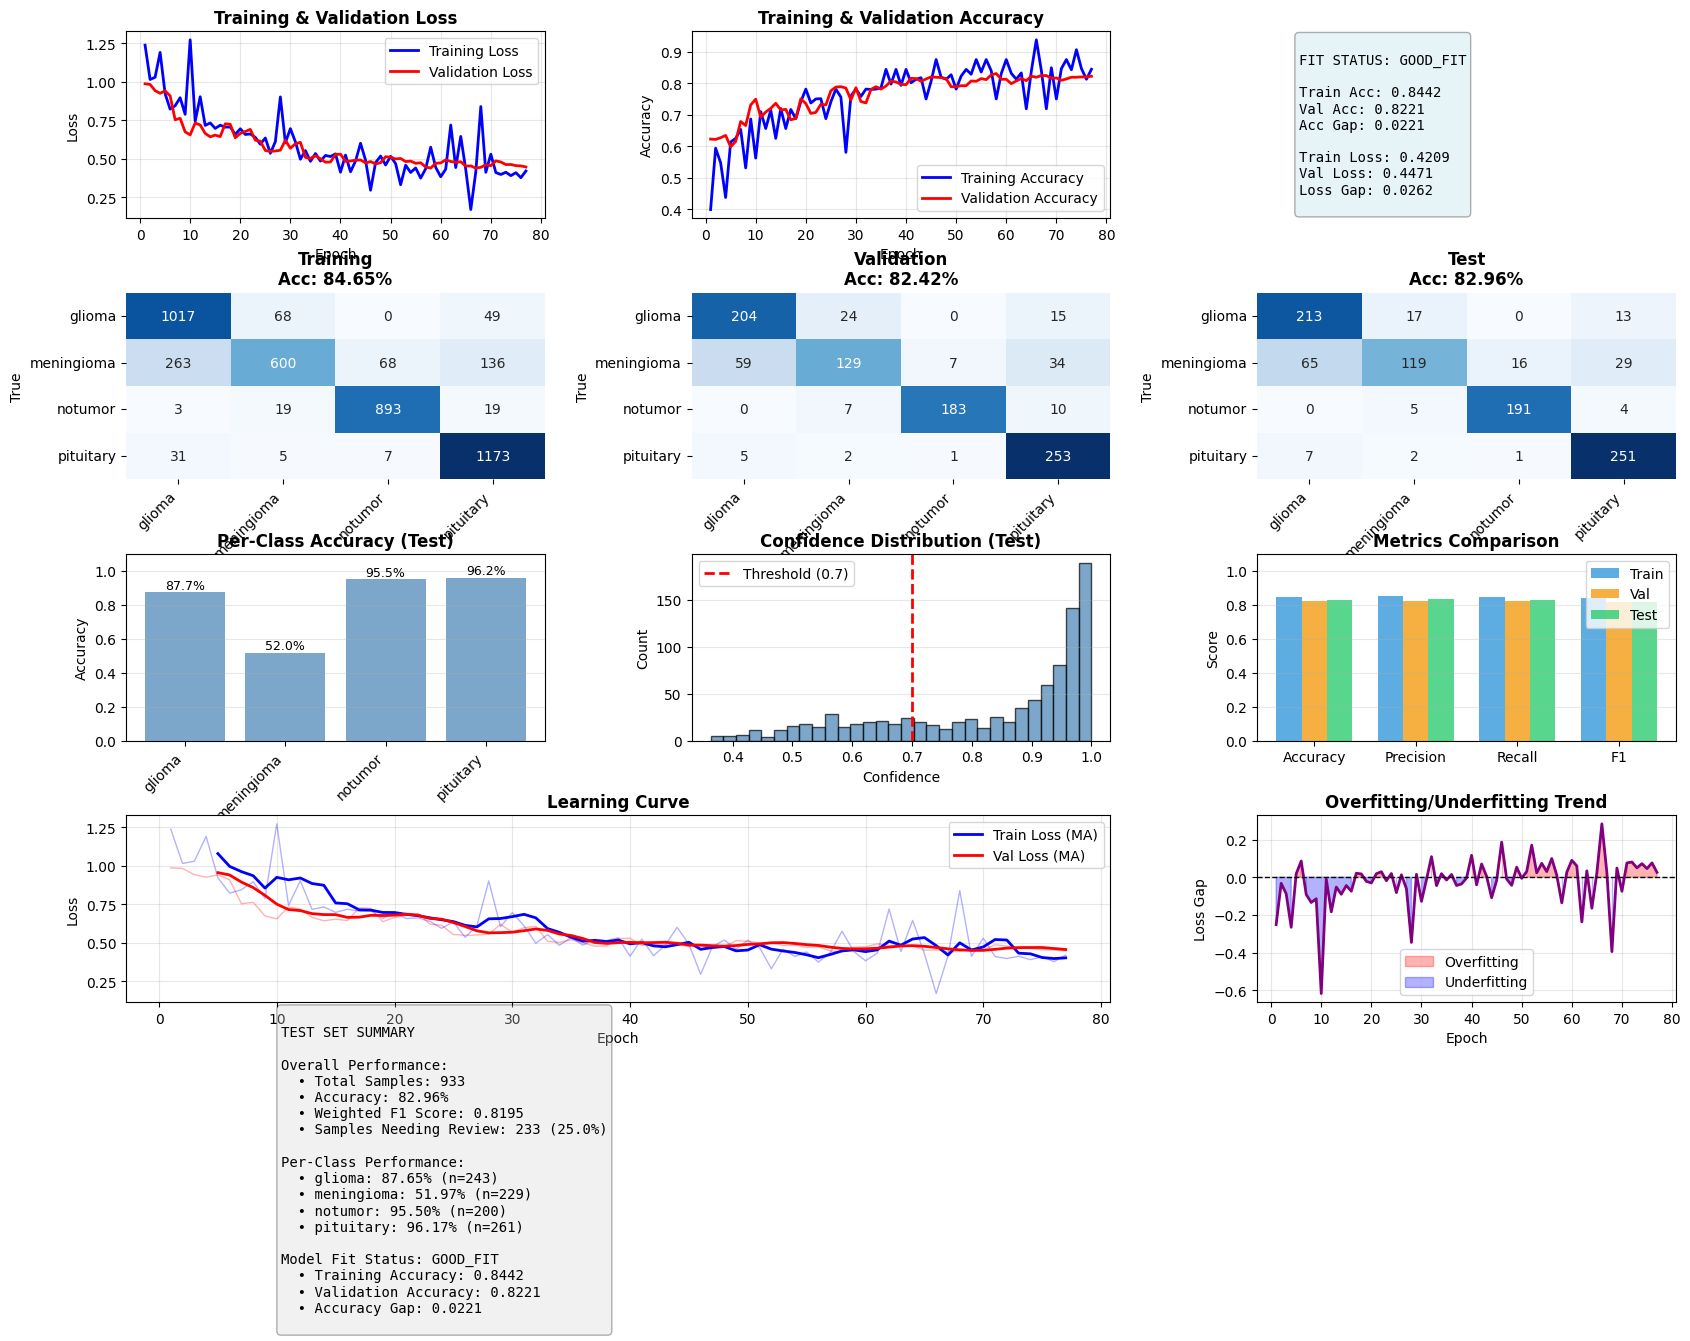


✅ Comprehensive analysis saved: training/results_mri_multiclass/comprehensive_analysis.png

CLASSIFICATION REPORT (TEST SET)
              precision    recall  f1-score   support

      glioma     0.7474    0.8765    0.8068       243
  meningioma     0.8322    0.5197    0.6398       229
     notumor     0.9183    0.9550    0.9363       200
   pituitary     0.8451    0.9617    0.8996       261

    accuracy                         0.8296       933
   macro avg     0.8357    0.8282    0.8206       933
weighted avg     0.8322    0.8296    0.8195       933


FINAL SUMMARY

MODEL FIT STATUS: ✅ GOOD_FIT

METRICS:
  Training Accuracy:    0.8442
  Validation Accuracy:  0.8221
  Accuracy Gap:         0.0221
  Training Loss:        0.4209
  Validation Loss:      0.4471
  Loss Gap:             0.0262

RECOMMENDATIONS:
  1. Model is performing well!
  2. Consider deploying this model


Test Set Performance:
  Total samples: 933
  Overall accuracy: 82.96%
  Weighted F1 Score: 0.8195
  Requiring hu

In [ ]:


if __name__ == "__main__":
    main()